# Quoted passages analysis

What are the differences between words that are used between quotes and words that aren't?

Steps:

1. Load the full annotations
2. Pick the quoted passages by class: SQ, NSQ (We keep SQ+NSQ out)
3. Keep unigrams only

## Downloading the necessary lexica

Here are instructions on how to download the resources used in this notebook. You need to specify the paths in the next cell.

* The **concreteness** dataset by Brysbaert et al., (2014) was downloaded from [this repository](https://github.com/ArtsEngine/concreteness?tab=readme-ov-file) and turned into a `.csv` file. 
* The **subjectivity** lexicon by Wilson et al., (2005) can be downloaded from [this website](https://mpqa.cs.pitt.edu/lexicons/subj_lexicon/). Specify the path to the only `.tff` file.
* The **SO-CAL** lexicon (Taboada et al., 2011) used for **intensity** can be downloaded from [this repository](https://github.com/sfu-discourse-lab/SO-CAL). Specify the path where the pos-specific files are located.
* The **NRC Word-Emotion Association Lexicon** (Mohammad and Turney, 2013) used for **polarity** can be downloaded from [this website](http://saifmohammad.com/WebPages/NRC-Emotion-Lexicon.htm). Specify the path to the `NRC-Emotion-Lexicon-Wordlevel-v0.92.txt` file.




In [ ]:
path_to_concreteness_dataset = ""
path_to_subjectivity_dataset = ""
path_to_socal_dir = ""
path_to_nrc = ""

In [2]:
import json
from utils import get_all_labels, get_labels_one_level, HIGH_LEVEL
from collections import defaultdict
import re
#from nltk import pos_tag, sent_tokenize, word_tokenize
import spacy
from collections import Counter
import numpy as np
from scipy.stats import chi2_contingency

# You may need to run this the first time:
# python -m spacy download en_core_web_sm


def transform_high_level_labels(labels):
    if labels == ("Scare quotes",):
        return "SQ"
    elif labels == ("Non-scare quotes",):
        return "NSQ"
    elif len(labels) == 2:
        return "SQ+NSQ"
    else:
        print("Could not transform labels:", labels)
        return "UNKNOWN"
    


/home/aina/miniforge3/envs/forconvokit/lib/python3.9/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647327249/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/aina/miniforge3/envs/forconvokit/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
nlp = spacy.load("en_core_web_sm")

## Loading annotations

And organize them by class

In [4]:
full_corpus = json.load(open("annotated_corpus.json", "r"))
corpus = [item for item in full_corpus if "Discard" not in get_all_labels(item)]

In [5]:
quoted_passages_by_sq = {'SQ':[], 'NSQ':[], 'SQ+NSQ':[]}

for item in corpus:
    hl_label = transform_high_level_labels(get_labels_one_level(item, HIGH_LEVEL, ignore_unsure_ambiguous=True))
    quoted_passage = item['data']['quoted_passage'].lower()
    ann_utt = item['data']['conversation'][item['data']['annotated_utt_index']]
    utterance_text = ann_utt['text']
    start = ann_utt['quote_start']
    end   = ann_utt['quote_end']

    # Verify the stored offset; fall back to string search if it doesn't match
    if utterance_text[start:end].lower() != quoted_passage:
        idx = utterance_text.lower().find(quoted_passage)
        if idx != -1:
            start = idx
            end   = idx + len(quoted_passage)
        else:
            # Cannot locate the passage — skip this item
            print("Cannot locate passage")
            continue

    quoted_passages_by_sq[hl_label].append({
        'passage':   quoted_passage,
        'utterance': utterance_text,
        'start':     start,
        'end':       end,
    })


In [6]:
# Sanity check: verify that text[start:end] == quoted_passage for every collected item
mismatches = []
for clas in quoted_passages_by_sq:
    for item in quoted_passages_by_sq[clas]:
        extracted = item['utterance'][item['start']:item['end']].lower()
        if extracted != item['passage']:
            mismatches.append(item)

total = sum(len(v) for v in quoted_passages_by_sq.values())
if mismatches:
    print(f"WARNING: {len(mismatches)} offset mismatches remain after fallback!")
    for m in mismatches[:5]:
        print(m)
else:
    print(f"✓ All {total} offsets verified: text[start:end] matches quoted_passage for every item.")


✓ All 2500 offsets verified: text[start:end] matches quoted_passage for every item.


## PoS analysis

Extract the sentence where the usage happened, pos-tag it and obtain the postag of the quoted passage. Store the info

In [7]:
def get_target_pos(utterance_text: str, start: int, end: int):
    """
    Return the POS tag(s) of the token(s) covering [start:end] in utterance_text.
    - If a single content token, returns a string (e.g. "NOUN").
    - If multiple content tokens, returns a list of (token_text, pos) tuples.
    """
    doc = nlp(utterance_text)

    overlapping = [
        token for token in doc
        if token.idx < end and (token.idx + len(token.text)) > start
    ]

    if not overlapping:
        raise RuntimeError(
            f"No token overlaps the span [{start}:{end}] in: {utterance_text!r}"
        )

    # Filter out punctuation/space tokens when possible (e.g. surrounding quote marks)
    content_tokens = [t for t in overlapping if not (t.is_punct or t.is_space)]
    if not content_tokens:
        content_tokens = overlapping  # fallback if only punctuation covered the span

    if len(content_tokens) == 1:
        return content_tokens[0].pos_  # coarse POS e.g. "NOUN", "VERB"
    else:
        return [(t.text, t.pos_) for t in content_tokens]


In [8]:
pos_by_sq = dict()

for clas in quoted_passages_by_sq:
    pos_by_sq[clas] = []
    for item in quoted_passages_by_sq[clas]:
        qp = item['passage']
        target_pos = get_target_pos(item['utterance'], item['start'], item['end'])
        if len(qp.split()) > 1 or isinstance(target_pos, list):
            # not a unigram
            continue
        pos_by_sq[clas].append(target_pos)
        item['pos'] = target_pos


#### Check distribution of PoS in every class

In [9]:
pos_counters = dict()
for clas in pos_by_sq:
    print("Total number of analyzable unigrams in class", clas, ":", len(pos_by_sq[clas]))
    c = Counter(pos_by_sq[clas])
    pos_counters[clas] = c    
    print("Pos distribution:")
    for k in c:
        print(k, np.round(c[k]/sum(c.values())*100,1), c[k])
    

Total number of analyzable unigrams in class SQ : 774
Pos distribution:
VERB 18.9 146
PROPN 1.6 12
ADJ 35.7 276
NOUN 39.5 306
PRON 0.9 7
ADP 0.3 2
ADV 2.2 17
AUX 0.5 4
INTJ 0.4 3
PUNCT 0.1 1
Total number of analyzable unigrams in class NSQ : 453
Pos distribution:
NOUN 35.3 160
VERB 6.6 30
ADP 0.7 3
PRON 4.4 20
PROPN 7.7 35
ADJ 30.9 140
INTJ 4.6 21
SCONJ 2.2 10
ADV 3.1 14
AUX 2.2 10
X 0.7 3
NUM 1.1 5
CCONJ 0.2 1
DET 0.2 1
Total number of analyzable unigrams in class SQ+NSQ : 214
Pos distribution:
NOUN 45.8 98
ADJ 32.7 70
VERB 6.5 14
ADP 0.9 2
ADV 4.2 9
PROPN 6.1 13
PRON 1.9 4
PUNCT 0.5 1
AUX 1.4 3


### PoS statistical analyses

Run Chi-square tests of independence separately for every PoS

In [10]:
done = []

for pos in pos_counters['NSQ']:
    done.append(pos)
    if pos_counters['NSQ'][pos] < 3:
        continue
    observations_nsq = [pos_counters['NSQ'][pos], sum(pos_counters['NSQ'].values())-pos_counters['NSQ'][pos]]
    if pos in pos_counters['SQ']:        
        observations_sq = [pos_counters['SQ'][pos], sum(pos_counters['SQ'].values())-pos_counters['SQ'][pos]]
        if pos_counters['SQ'][pos] < 3:
            continue
    else:
        observations_sq = [0, sum(pos_counters['SQ'].values())]
    
    observations = [observations_nsq, observations_sq]
    stat, pval, dfr, exp = chi2_contingency(observations, correction=True)
    if pval < 0.05:        
        print(pos, "p-value", np.round(pval, 3), "X2:", np.round(stat, 2), "--> SIGNIFICANT RESULT")
    else:
        print(pos, "p-value", np.round(pval, 3), "X2:", np.round(stat, 2))

    

print("Any PoS not covered?:", [pos for pos in pos_counters['SQ'] if pos not in done])
        

NOUN p-value 0.159 X2: 1.98
VERB p-value 0.0 X2: 33.86 --> SIGNIFICANT RESULT
PRON p-value 0.0 X2: 14.77 --> SIGNIFICANT RESULT
PROPN p-value 0.0 X2: 27.93 --> SIGNIFICANT RESULT
ADJ p-value 0.102 X2: 2.67
INTJ p-value 0.0 X2: 24.72 --> SIGNIFICANT RESULT
SCONJ p-value 0.0 X2: 14.6 --> SIGNIFICANT RESULT
ADV p-value 0.439 X2: 0.6
AUX p-value 0.016 X2: 5.82 --> SIGNIFICANT RESULT
X p-value 0.095 X2: 2.78
NUM p-value 0.014 X2: 6.07 --> SIGNIFICANT RESULT
Any PoS not covered?: ['PUNCT']


## Polysemy (number of senses)

Pick content words that are in WordNet.


In [11]:
from nltk.corpus import wordnet as wn
from nltk import WordNetLemmatizer

def transform_pos(pos):
    if pos == "ADV":
        return 'r'
    else:
        return pos[0].lower()

In [12]:

lemmatizer = WordNetLemmatizer()
polysemy_by_sq = dict()

for clas in quoted_passages_by_sq:    
    polysemy_by_sq[clas] = [] # PoS-dependent polysemy
    
    for item in quoted_passages_by_sq[clas]:        
        if 'pos' not in item: # Do the analysis only for items for which we have a PoS tag (i.e. unigrams)
            continue
        
        pos = item['pos']            
        if pos not in ["NOUN","ADJ","ADV","VERB"]:
            continue
        pos = transform_pos(pos)
        
        qp = item['passage']
        lemma = lemmatizer.lemmatize(qp, pos)
        
        number_of_senses = len(wn.synsets(lemma))
        
        if number_of_senses > 0: # If a word has 0 senses it means it is not in WordNet, so we ignore it
            polysemy_by_sq[clas].append(number_of_senses)
            item['number_of_senses'] = number_of_senses

Check polysemy statistics by class

In [13]:
print("Polysemy statistics:")
for clas in polysemy_by_sq:
    print(clas)
    print("average num of senses:", np.average(polysemy_by_sq[clas]))
    print("max num of senses:", np.max(polysemy_by_sq[clas]))
    print("median num of senses:", np.median(polysemy_by_sq[clas]))    
    print("number of items:", len(polysemy_by_sq[clas]))
    print()
    

Polysemy statistics:
SQ
average num of senses: 8.33527696793003
max num of senses: 75
median num of senses: 5.0
number of items: 686

NSQ
average num of senses: 6.486666666666666
max num of senses: 36
median num of senses: 4.0
number of items: 300

SQ+NSQ
average num of senses: 6.982857142857143
max num of senses: 43
median num of senses: 5.0
number of items: 175



### Polysemy statistical significance testing

Check if distributions are normal with Shapiro-Wilk. If not normal, we will run Mann-Whitney tests

In [14]:
from scipy.stats import shapiro

for clas in polysemy_by_sq:
    print(clas, shapiro(polysemy_by_sq[clas]))

SQ ShapiroResult(statistic=0.7194416522979736, pvalue=2.436018232448099e-32)
NSQ ShapiroResult(statistic=0.70740807056427, pvalue=1.500214522564504e-22)
SQ+NSQ ShapiroResult(statistic=0.6585630774497986, pvalue=1.4203152270726983e-18)


In [15]:
from scipy.stats import mannwhitneyu

U, pval = mannwhitneyu(polysemy_by_sq['SQ'], polysemy_by_sq['NSQ'])
print("Mann-Whitney U test comparing PoS-dependent polysemy between SQ and NSQ:")
print("U statistic:", U)
if pval < 0.05:
    print("p-value:", pval, "--> SIGNIFICANT RESULT")
else:
    print("p-value:", pval)

Mann-Whitney U test comparing PoS-dependent polysemy between SQ and NSQ:
U statistic: 116552.0
p-value: 0.0008613155494644372 --> SIGNIFICANT RESULT


Let's also look at the histograms

(array([124.,  62.,  39.,  30.,   6.,   8.,  10.,   2.,   1.,   3.,   1.,
          6.,   1.,   1.,   6.]),
 array([ 1.        ,  3.33333333,  5.66666667,  8.        , 10.33333333,
        12.66666667, 15.        , 17.33333333, 19.66666667, 22.        ,
        24.33333333, 26.66666667, 29.        , 31.33333333, 33.66666667,
        36.        ]),
 <BarContainer object of 15 artists>)

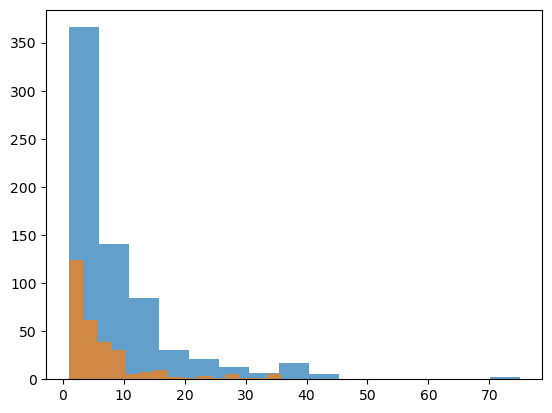

In [16]:
import matplotlib.pyplot as plt
plt.hist(polysemy_by_sq['SQ'], bins=15, alpha=0.7)
plt.hist(polysemy_by_sq['NSQ'], bins=15, alpha=0.7)

## Frequency

We will try both with zipf_frequency and word_frequency.

In [17]:
from wordfreq import zipf_frequency, word_frequency

zfreq_by_sq = dict()
wfreq_by_sq = dict()

for clas in quoted_passages_by_sq:    
    zfreq_by_sq[clas] = []
    wfreq_by_sq[clas] = []
    
    for item in quoted_passages_by_sq[clas]:        
        if 'pos' not in item:
            continue
        
        zfreq = zipf_frequency(item['passage'], 'en')
        wfreq = word_frequency(item['passage'], 'en')           
        
        zfreq_by_sq[clas].append(zfreq)
        item['zipf_freq'] = zfreq
        
        wfreq_by_sq[clas].append(wfreq)
        item['word_freq'] = wfreq
        

### Observe frequency statistics (zipf freq)

In [18]:

for clas in zfreq_by_sq:
    print(clas)
    print("average freq:", np.average(zfreq_by_sq[clas]))
    print("max freq:", np.max(zfreq_by_sq[clas]))
    print("median freq:", np.median(zfreq_by_sq[clas]))
    print("number of 0s:", zfreq_by_sq[clas].count(0))
    print("number of elements:", len(zfreq_by_sq[clas]))
    print()
    

SQ
average freq: 4.389883720930232
max freq: 7.01
median freq: 4.56
number of 0s: 8
number of elements: 774

NSQ
average freq: 4.526048565121413
max freq: 7.41
median freq: 4.73
number of 0s: 10
number of elements: 453

SQ+NSQ
average freq: 4.566542056074766
max freq: 7.27
median freq: 4.71
number of 0s: 3
number of elements: 214



In [19]:

for clas in zfreq_by_sq:
    print(clas)
    print("average freq:", np.average(zfreq_by_sq[clas]))
    print("max freq:", np.max(zfreq_by_sq[clas]))
    print("median freq:", np.median(zfreq_by_sq[clas]))
    print("number of 0s:", zfreq_by_sq[clas].count(0))
    print("number of elements:", len(zfreq_by_sq[clas]))
    print()
    

SQ
average freq: 4.389883720930232
max freq: 7.01
median freq: 4.56
number of 0s: 8
number of elements: 774

NSQ
average freq: 4.526048565121413
max freq: 7.41
median freq: 4.73
number of 0s: 10
number of elements: 453

SQ+NSQ
average freq: 4.566542056074766
max freq: 7.27
median freq: 4.71
number of 0s: 3
number of elements: 214



### Zipf frequency statistical tests

In [20]:
for clas in zfreq_by_sq:
    print(clas, shapiro(zfreq_by_sq[clas])) 


SQ ShapiroResult(statistic=0.9533231258392334, pvalue=5.992869063140265e-15)
NSQ ShapiroResult(statistic=0.9275244474411011, pvalue=5.409259127317316e-14)
SQ+NSQ ShapiroResult(statistic=0.9247280955314636, pvalue=5.328765873002794e-09)


In [21]:
U, pval = mannwhitneyu(zfreq_by_sq['SQ'], zfreq_by_sq['NSQ'])
print("Mann-Whitney U test comparing Zipf frequency between SQ and NSQ:")
print("U statistic:", U)
if pval < 0.05:
    print("p-value:", pval, "--> SIGNIFICANT RESULT")
else:
    print("p-value:", pval)

Mann-Whitney U test comparing Zipf frequency between SQ and NSQ:
U statistic: 158245.5
p-value: 0.004386156942046144 --> SIGNIFICANT RESULT


### Observe frequency statistics (word freq)

In [22]:

for clas in wfreq_by_sq:
    print(clas)
    print("average freq:", np.average(wfreq_by_sq[clas]))
    print("median freq:", np.median(wfreq_by_sq[clas]))
    print("max freq:", np.max(wfreq_by_sq[clas]))
    print("number of 0s:", wfreq_by_sq[clas].count(0))
    print("number of elements:", len(wfreq_by_sq[clas]))
    print()
    

SQ
average freq: 0.00018546996950904394
median freq: 3.63e-05
max freq: 0.0102
number of 0s: 8
number of elements: 774

NSQ
average freq: 0.0005110637671744549
median freq: 5.37e-05
max freq: 0.0257
number of 0s: 9
number of elements: 453

SQ+NSQ
average freq: 0.00033909386168224303
median freq: 5.13e-05
max freq: 0.0186
number of 0s: 3
number of elements: 214



In [23]:
for clas in wfreq_by_sq:
    print(clas, shapiro(wfreq_by_sq[clas])) 


SQ ShapiroResult(statistic=0.3056296706199646, pvalue=0.0)
NSQ ShapiroResult(statistic=0.2701103687286377, pvalue=1.0619792259928806e-38)
SQ+NSQ ShapiroResult(statistic=0.18135839700698853, pvalue=1.4567804817085197e-29)


In [24]:
U, pval = mannwhitneyu(wfreq_by_sq['SQ'], wfreq_by_sq['NSQ'])
print("Mann-Whitney U test comparing word frequency between SQ and NSQ:")
print("U statistic:", U)
if pval < 0.05:
    print("p-value:", pval, "--> SIGNIFICANT RESULT")
else:
    print("p-value:", pval)

Mann-Whitney U test comparing word frequency between SQ and NSQ:
U statistic: 158237.0
p-value: 0.004366647551534301 --> SIGNIFICANT RESULT


## Concreteness/abstractness

To analyze the concreteness of lexical items, we relied on the concreteness ratings by (Brysbaert et al., 2014), who provide mean concreteness values for over 39,000 English word lemmas and common two-word expressions. The ratings, based on crowd-sourced judgments from more than 4,000
participants, use a five-point scale ranging from 1 (very abstract) to 5 (very concrete).

#### Load ratings

In [25]:
concreteness_dict = dict()
with open(path_to_concreteness_dataset) as f:
    for l in f.readlines():
        l = l.strip().split("\t")
        if l[0] != "Word":
            concreteness_dict[l[0]] = float(l[2])
            

In [26]:
len(concreteness_dict)

39954

If a word is not in the dataset, try with its lemma

In [27]:

concreteness_by_sq = dict()

for clas in quoted_passages_by_sq:    
    concreteness_by_sq[clas] = []
        
    for item in quoted_passages_by_sq[clas]:        
        if 'pos' not in item:
            continue       
        
        if item['passage'] in concreteness_dict:
            conc = concreteness_dict[item['passage']]
        else:
            tp = transform_pos(item['pos'])
            if tp in ['n','v','a','r']:
                lemma = lemmatizer.lemmatize(item['passage'], tp)
            else:
                lemma = lemmatizer.lemmatize(item['passage'])
            
            if lemma in concreteness_dict:
                conc = concreteness_dict[lemma]
            else:
                conc = None
        
        if conc:
            concreteness_by_sq[clas].append(conc)
            item['concreteness'] = conc


### Observe concreteness statistics

In [28]:

for clas in concreteness_by_sq:
    print(clas)
    print("average concreteness:", np.average(concreteness_by_sq[clas]))
    print("max concreteness:", np.max(concreteness_by_sq[clas]))
    print("median concreteness:", np.median(concreteness_by_sq[clas]))    
    print("number of elements:", len(concreteness_by_sq[clas]))
    print()
    

SQ
average concreteness: 2.588787446504993
max concreteness: 4.96
median concreteness: 2.37
number of elements: 701

NSQ
average concreteness: 2.5877956989247313
max concreteness: 4.96
median concreteness: 2.365
number of elements: 372

SQ+NSQ
average concreteness: 2.4176439790575914
max concreteness: 4.93
median concreteness: 2.12
number of elements: 191



### Concreteness statistical test

In [29]:
for clas in concreteness_by_sq:
    print(clas, shapiro(concreteness_by_sq[clas]))  


SQ ShapiroResult(statistic=0.9298869371414185, pvalue=1.372866451416401e-17)
NSQ ShapiroResult(statistic=0.9245405793190002, pvalue=9.59332873556873e-13)
SQ+NSQ ShapiroResult(statistic=0.8858543038368225, pvalue=7.013604974570598e-11)


In [30]:
U, pval = mannwhitneyu(concreteness_by_sq['SQ'], concreteness_by_sq['NSQ'])
print("Mann-Whitney U test comparing concreteness between SQ and NSQ:")
print("U statistic:", U)
if pval < 0.05:
    print("p-value:", pval, "--> SIGNIFICANT RESULT")
else:
      print("p-value:", pval)

Mann-Whitney U test comparing concreteness between SQ and NSQ:
U statistic: 133027.5
p-value: 0.5845846056393108


## Subjectivity

In [31]:

subjdict = dict()

with open(path_to_subjectivity_dataset) as f:
    for l in f:
        elements = l.strip().split()
        typee = [x for x in elements if x.startswith("type=")]
        word = [x for x in elements if x.startswith("word1=")]
        typee = typee[0]
        word = word[0]
        typee = typee.split("=")[1]
        word = word.split("=")[1]
        subjdict[word] = typee      
        

In [32]:

subj_by_sq = dict()

for clas in quoted_passages_by_sq:
    subj_by_sq[clas] = []    
    for item in quoted_passages_by_sq[clas]:
        utterance = item['utterance']
        qp = item['passage']
        if qp in subjdict:
            subj_by_sq[clas].append(subjdict[qp])
            item['subjectivity'] = subjdict[qp]  

### Observe subjectivity distribution

In [33]:
      
subj_counters = dict()
for clas in subj_by_sq:
    print("total number of analyzable unigrams in class", clas, ":", len(subj_by_sq[clas]))
    c = Counter(subj_by_sq[clas])
    subj_counters[clas] = c    
    print("subjectivity distribution:")
    for k in c:
        print(k, np.round(c[k]/sum(c.values())*100,1))
    print()
    

total number of analyzable unigrams in class SQ : 327
subjectivity distribution:
weaksubj 54.1
strongsubj 45.9

total number of analyzable unigrams in class NSQ : 168
subjectivity distribution:
strongsubj 55.4
weaksubj 44.6

total number of analyzable unigrams in class SQ+NSQ : 99
subjectivity distribution:
weaksubj 45.5
strongsubj 54.5



### Subjectivity statistical results

In [34]:
observations_nsq = [subj_counters['NSQ']['weaksubj'], subj_counters['NSQ']['strongsubj']]
observations_sq = [subj_counters['SQ']['weaksubj'], subj_counters['SQ']['strongsubj']]

observations = [observations_nsq, observations_sq]
stat, pval, dfr, exp = chi2_contingency(observations, correction=True)
if pval < 0.05:
    print("p-value", np.round(pval, 3), "X2:", np.round(stat, 2), "--> SIGNIFICANT RESULT")
else:
    print("p-value", np.round(pval, 3), "X2:", np.round(stat, 2))


p-value 0.057 X2: 3.63


## Intensity (SO-CAL)



In [35]:

socal = dict()
print("Loading SO-CAL lexicon...")
print("Number of entries by PoS:")
for pos in ['adj','adv','noun','verb']:
    socal[pos] = dict()
    with open(path_to_socal_dir + "/" + pos + "_dictionary1.11.txt",encoding='latin1') as f:
        for l in f:
            l = l.strip().split("\t")
            socal[pos][l[0]] = int(l[1])

    print(pos, len(socal[pos]))



Loading SO-CAL lexicon...
Number of entries by PoS:
adj 2819
adv 877
noun 1539
verb 1130


In [36]:
sent_by_sq = dict()
intensity_by_sq = dict()

for clas in quoted_passages_by_sq:
    sent_by_sq[clas] = []    
    intensity_by_sq[clas] = []    
    for item in quoted_passages_by_sq[clas]:
        utterance = item['utterance']
        qp = item['passage']
        if 'pos' in item:
            pos = item['pos'].lower()        
        else: 
            pos = ''
        # try to take the word in the correct pos. If it is not available, take the word in any other pos if available.
        if pos in socal and qp in socal[pos]:
            sent_by_sq[clas].append(socal[pos][qp])
            intensity_by_sq[clas].append(abs(socal[pos][qp]))            
            item['socal_intensity'] = abs(socal[pos][qp])
        else:
            # take the averages of all scores it appears with
            scores = []
            for pos2 in socal:
                if pos2 != pos:
                    if qp in socal[pos2]:
                        scores.append(socal[pos2][qp])                        
            if scores:
                sent_by_sq[clas].append(np.average(scores))
                intensity_by_sq[clas].append(abs(np.average(scores)))                
                item['socal_intensity'] = abs(np.average(scores))

    

### Observe intensity statistics

In [37]:
   
for clas in intensity_by_sq:
    print(clas, "average intensity:", np.average(intensity_by_sq[clas]))
    print(clas, "median intensity:", np.median(intensity_by_sq[clas]))
    print(clas, "max freq:", np.max(intensity_by_sq[clas]))    
    print(clas, "number of elements:", len(intensity_by_sq[clas]))
    print()
    
    

SQ average intensity: 2.064784053156146
SQ median intensity: 2.0
SQ max freq: 5.0
SQ number of elements: 301

NSQ average intensity: 2.2183098591549295
NSQ median intensity: 2.0
NSQ max freq: 5.0
NSQ number of elements: 142

SQ+NSQ average intensity: 2.2444444444444445
SQ+NSQ median intensity: 2.0
SQ+NSQ max freq: 5.0
SQ+NSQ number of elements: 90



### Intensity statistical significance

In [38]:
for clas in intensity_by_sq:
    print(clas, shapiro(intensity_by_sq[clas]))
    


SQ ShapiroResult(statistic=0.8500410318374634, pvalue=1.9810283485908428e-16)
NSQ ShapiroResult(statistic=0.8695511221885681, pvalue=7.592265149902744e-10)
SQ+NSQ ShapiroResult(statistic=0.9068374037742615, pvalue=8.294524377561174e-06)


In [39]:
U, pval = mannwhitneyu(intensity_by_sq['SQ'], intensity_by_sq['NSQ'])
print("Mann-Whitney U test comparing SO-CAL intensity between SQ and NSQ:")
print("U statistic:", U)
if pval < 0.05:
    print("p-value:", pval, "--> SIGNIFICANT RESULT")   
else:
    print("p-value:", pval)

Mann-Whitney U test comparing SO-CAL intensity between SQ and NSQ:
U statistic: 19730.0
p-value: 0.17258330781394704


# Polarity (NRC Emotion lexicon)

In [40]:
nrc_first = dict()

with open(path_to_nrc) as f:
    for l in f:
        l = l.strip().split("\t")
        word, emotion, score = l
        if emotion in ['positive','negative']:
            if word not in nrc_first:
                nrc_first[word] = dict()
            nrc_first[word][emotion] = int(score)
        

Turn words that have 0 in "positive" and "negative" into a "neutral" class. And words that are both positive and negative into a "both" class.

In [41]:

nrc = dict()

for word in nrc_first:
    if nrc_first[word]['positive'] == nrc_first[word]['negative'] == 0:
        nrc[word] = 'neutral'
    elif nrc_first[word]['positive'] == nrc_first[word]['negative'] == 1:
        nrc[word] = 'both'
    elif nrc_first[word]['positive'] == 1 and nrc_first[word]['negative'] == 0:
        nrc[word] = 'positive'
    elif nrc_first[word]['positive'] == 0 and nrc_first[word]['negative'] == 1:
        nrc[word] = 'negative'
    
    
    

In [42]:
nrc_by_sq = dict()

for clas in quoted_passages_by_sq:
    nrc_by_sq[clas] = []        
    for item in quoted_passages_by_sq[clas]:
        utterance = item['utterance']
        qp = item['passage']
        if qp in nrc:
            nrc_by_sq[clas].append(nrc[qp])            
            item['nrc'] = nrc[qp]
        
    
    

In [43]:
nrc_counters = dict()
for clas in nrc_by_sq:
    print("Total number of analyzable unigrams in class", clas, ":", len(nrc_by_sq[clas]))
    c = Counter(nrc_by_sq[clas])
    nrc_counters[clas] = c    
    print("Polarity distribution:")
    for k in c:
        print(k, np.round(c[k]/sum(c.values())*100,1))
    print()
    

Total number of analyzable unigrams in class SQ : 428
Polarity distribution:
neutral 42.3
positive 33.2
negative 24.3
both 0.2

Total number of analyzable unigrams in class NSQ : 211
Polarity distribution:
neutral 32.7
positive 33.6
negative 31.8
both 1.9

Total number of analyzable unigrams in class SQ+NSQ : 122
Polarity distribution:
neutral 38.5
positive 27.0
negative 33.6
both 0.8



In [44]:
nrc_counters = dict()
for clas in nrc_by_sq:
    print("Total number of analyzable unigrams in class", clas, ":", len(nrc_by_sq[clas]))
    c = Counter(nrc_by_sq[clas])
    nrc_counters[clas] = c    
    print("Polarity distribution:")
    for k in c:
        print(k, np.round(c[k]/sum(c.values())*100,1))
    print()
    

Total number of analyzable unigrams in class SQ : 428
Polarity distribution:
neutral 42.3
positive 33.2
negative 24.3
both 0.2

Total number of analyzable unigrams in class NSQ : 211
Polarity distribution:
neutral 32.7
positive 33.6
negative 31.8
both 1.9

Total number of analyzable unigrams in class SQ+NSQ : 122
Polarity distribution:
neutral 38.5
positive 27.0
negative 33.6
both 0.8



### Polarity statistical test with three classes: positive, negative and neutral

In [45]:
observations_nsq = [nrc_counters['NSQ']['positive'], nrc_counters['NSQ']['negative'], nrc_counters['NSQ']['neutral']]
observations_sq = [nrc_counters['SQ']['positive'], nrc_counters['SQ']['negative'], nrc_counters['SQ']['neutral']]

observations = [observations_nsq, observations_sq]
stat, pval, dfr, exp = chi2_contingency(observations, correction=True)
if pval < 0.05:
    print("p-value", np.round(pval, 3), "X2:", np.round(stat, 2), "--> SIGNIFICANT RESULT")
else:
    print("p-value", np.round(pval, 3), "X2:", np.round(stat, 2))


p-value 0.044 X2: 6.26 --> SIGNIFICANT RESULT
